In [1]:
fn =  f"E:/000_FuJian/fnl/gdas1.fnl0p25.2024040500.f00.grib2"


In [2]:
from eccodes import *
import numpy as np
import xarray as xr 
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import cartopy.crs as crs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.io.shapereader as shapereader
from datetime import  datetime, timedelta
import os 

In [3]:
#fn =  f"E:/000_FuJian/fnl/gdas1.fnl0p25.2024040500.f00.grib2"
ds = xr.open_dataset(fn, engine='cfgrib',backend_kwargs={'filter_by_keys': {'typeOfLevel': 'isobaricInhPa'}})
#ds

skipping variable: paramId==228164 shortName='tcc'
Traceback (most recent call last):
  File "D:\miniconda3\envs\py39\lib\site-packages\cfgrib\dataset.py", line 680, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "D:\miniconda3\envs\py39\lib\site-packages\cfgrib\dataset.py", line 611, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='isobaricInhPa' value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  975.,  950.,  925.,  900.,  850.,  800.,  750.,  700.,
        650.,  600.,  550.,  500.,  450.,  400.,  350.,  300.,  250.,
        200.,  150.,  100.,   70.,   50.,   40.,   30.,   20.,   15.,
         10.,    7.,    5.,    3.,    2.,    1.])) new_value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  975.,  950.,  925.,  900.,  850.,  800.,  750.,  700.,
        650.,  600.,  550.,  500.,  450.,  400.,  350.,  300.,  250.,
        200.,  150.,  100.,   50.]))
skippin

Text(0.5, 1.0, 'level = 500 hPa, time = 2024040500')

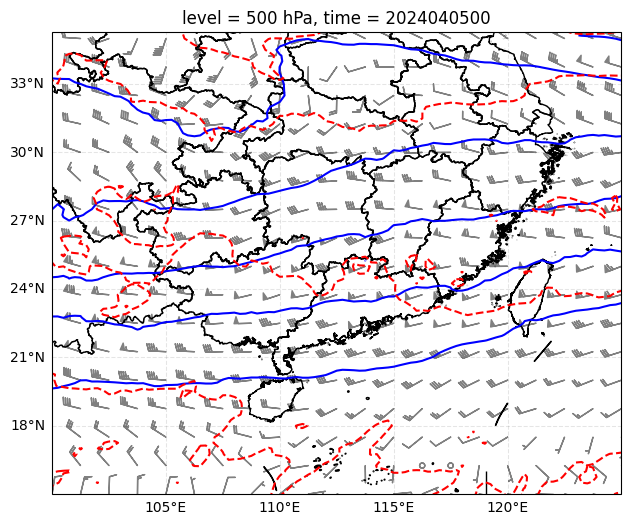

In [4]:
valid = datetime(2024,4,5,0)
title = f"level = 500 hPa, time = {valid:%Y%m%d%H}"

cart_proj = crs.PlateCarree()
fig = plt.figure(figsize=(12,6))
ax = plt.axes(projection=cart_proj)
levels = np.arange(520., 600., 4.)#500pha
#levels = np.arange(1500., 1260., 4.)#500pha
gh = plt.contour(ds.longitude, ds.latitude, ds.gh.sel(isobaricInhPa=500) / 10.,
                  levels=levels, colors="blue",
                  transform=crs.PlateCarree())
plt.clabel(gh, inline=True, inline_spacing=1, fontsize=10, fmt="%i")

levels = np.arange(-40., 40., 4.)#500pha
#levels = np.arange(-60., 60., 4.)#500pha

tcontour = plt.contour(ds.longitude, ds.latitude, ds.t.sel(isobaricInhPa=500) - 273.15 ,
                  levels=levels, colors="red", 
                  transform=crs.PlateCarree())
plt.clabel(tcontour, inline=True, inline_spacing=1, fontsize=10, fmt="%i")

step = 5
wbar = ax.barbs(ds.longitude[::step], ds.latitude[::step],
            ds.u.sel(isobaricInhPa=500)[::step, ::step],
            ds.v.sel(isobaricInhPa=500)[::step, ::step],
      barb_increments={'half':2,'full':4,'flag':20},barbcolor="gray",
      transform=crs.PlateCarree(), length=5)

#extent=[115.5,120.5,23.5,28.5]  ## 经纬度范围 [西，东，南，北]
extent=[100,125,15,35] # 
#extent=[60,140,10,60] # 全国
ax.set_extent(extent)
gl = ax.gridlines(crs=crs.PlateCarree(),draw_labels=True,linewidth=0.8, color='k', alpha=0.1, linestyle='--')
gl.top_labels   = False    #关闭顶端标签
gl.right_labels = False  #关闭右侧标签
gl.xformatter = LONGITUDE_FORMATTER  #x轴设为经度格式
gl.yformatter = LATITUDE_FORMATTER   #y轴设为纬度格式
mfl    = r"E:/0_ditudate/矢量图/和鲸矢量图/province_9south.shp"
ax.add_geometries(shapereader.Reader(mfl).geometries(), crs=cart_proj, facecolor='none',edgecolor='k',linewidth=1)
plt.title(title)